In [ ]:
# ============================================
#Phase 2: Generating Hypothesis
# ============================================

import pandas as pd

df = pd.read_csv('../data/processed/user_level_ab_data_fixed.csv')

# Quick verification
print("Data loaded successfully!")
print(f"Shape: {df.shape}")
print(f"\nFirst 2 rows:")
print(df.head(2))
print(f"\nColumns: {df.columns.tolist()}")

Data loaded successfully!
Shape: (100000, 8)

First 2 rows:
   customer_id experiment_group  converted  revenue loyalty_tier device_type  \
0            1          control          0     0.00       Bronze      mobile   
1            2          control          1  1141.71       Silver      mobile   

   is_treatment  is_control  
0             0           1  
1             0           1  

Columns: ['customer_id', 'experiment_group', 'converted', 'revenue', 'loyalty_tier', 'device_type', 'is_treatment', 'is_control']


In [3]:
# Segment analysis by device_type
print("=" * 60)
print("SEGMENT ANALYSIS: DEVICE TYPE")
print("=" * 60)

# Check if device_type column exists
if 'device_type' in df.columns:
    device_results = df.groupby(['device_type', 'experiment_group'])['converted'].mean().unstack()
    device_results['lift_variant_a'] = (device_results['variant_a'] / device_results['control'] - 1) * 100
    device_results['lift_variant_b'] = (device_results['variant_b'] / device_results['control'] - 1) * 100
    print(device_results[['control', 'variant_a', 'variant_b', 'lift_variant_a', 'lift_variant_b']])
else:
    print("Column 'device_type' not found")
    print(f"Available columns: {df.columns.tolist()}")

# Segment analysis by loyalty_tier
print("\n" + "=" * 60)
print("SEGMENT ANALYSIS: LOYALTY TIER")
print("=" * 60)

if 'loyalty_tier' in df.columns:
    loyalty_results = df.groupby(['loyalty_tier', 'experiment_group'])['converted'].mean().unstack()
    loyalty_results['lift_variant_a'] = (loyalty_results['variant_a'] / loyalty_results['control'] - 1) * 100
    loyalty_results['lift_variant_b'] = (loyalty_results['variant_b'] / loyalty_results['control'] - 1) * 100
    print(loyalty_results[['control', 'variant_a', 'variant_b', 'lift_variant_a', 'lift_variant_b']])
else:
    print("Column 'loyalty_tier' not found")
    print(f"Available columns: {df.columns.tolist()}")

SEGMENT ANALYSIS: DEVICE TYPE
experiment_group   control  variant_a  variant_b  lift_variant_a  \
device_type                                                        
desktop           0.618858   0.614532   0.613029       -0.699016   
mobile            0.643189   0.647429   0.645872        0.659177   
tablet            0.000000        NaN   1.000000             NaN   

experiment_group  lift_variant_b  
device_type                       
desktop                -0.941900  
mobile                  0.417033  
tablet                       inf  

SEGMENT ANALYSIS: LOYALTY TIER
experiment_group   control  variant_a  variant_b  lift_variant_a  \
loyalty_tier                                                       
Bronze            0.600044   0.604636   0.601903        0.765207   
Gold              0.736396   0.738929   0.742334        0.343968   
Platinum          0.736989   0.735726   0.745955       -0.171431   
Silver            0.677622   0.676394   0.673642       -0.181247   

experiment_gr

In [4]:
# See what other columns might be useful for segmentation
print("\n" + "=" * 60)
print("AVAILABLE COLUMNS FOR SEGMENTATION")
print("=" * 60)

for col in df.columns:
    print(f"- {col}")

# Check unique values in each categorical column
print("\n" + "=" * 60)
print("UNIQUE VALUES IN CATEGORICAL COLUMNS")
print("=" * 60)

categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"\n{col}: {df[col].unique()[:5]}")  # Show first 5 unique values


AVAILABLE COLUMNS FOR SEGMENTATION
- customer_id
- experiment_group
- converted
- revenue
- loyalty_tier
- device_type
- is_treatment
- is_control

UNIQUE VALUES IN CATEGORICAL COLUMNS

experiment_group: <ArrowStringArray>
['control', 'variant_b', 'variant_a']
Length: 3, dtype: str

loyalty_tier: <ArrowStringArray>
['Bronze', 'Silver', 'Gold', 'Platinum']
Length: 4, dtype: str

device_type: <ArrowStringArray>
['mobile', 'desktop', 'tablet']
Length: 3, dtype: str


C:\Users\vaishnavi\AppData\Local\Temp\ipykernel_27164\348801609.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


In [ ]:
# ============================================
# ENSURE SEGMENT DATAFRAMES EXIST
# ============================================

# Recreate device_segment if needed
if 'device_segment' not in dir():
    device_segment = df.groupby(['device_type', 'experiment_group'])['converted'].mean().unstack()
    device_segment['lift_variant_a'] = (device_segment['variant_a'] / device_segment['control'] - 1) * 100
    device_segment['lift_variant_b'] = (device_segment['variant_b'] / device_segment['control'] - 1) * 100
    print("device_segment created")

# Recreate loyalty_segment if needed
if 'loyalty_segment' not in dir():
    loyalty_segment = df.groupby(['loyalty_tier', 'experiment_group'])['converted'].mean().unstack()
    loyalty_segment['lift_variant_a'] = (loyalty_segment['variant_a'] / loyalty_segment['control'] - 1) * 100
    loyalty_segment['lift_variant_b'] = (loyalty_segment['variant_b'] / loyalty_segment['control'] - 1) * 100
    print("loyalty_segment created")

print("\nVariables ready!!")

device_segment created
loyalty_segment created

Variables ready for Section 5 and 7


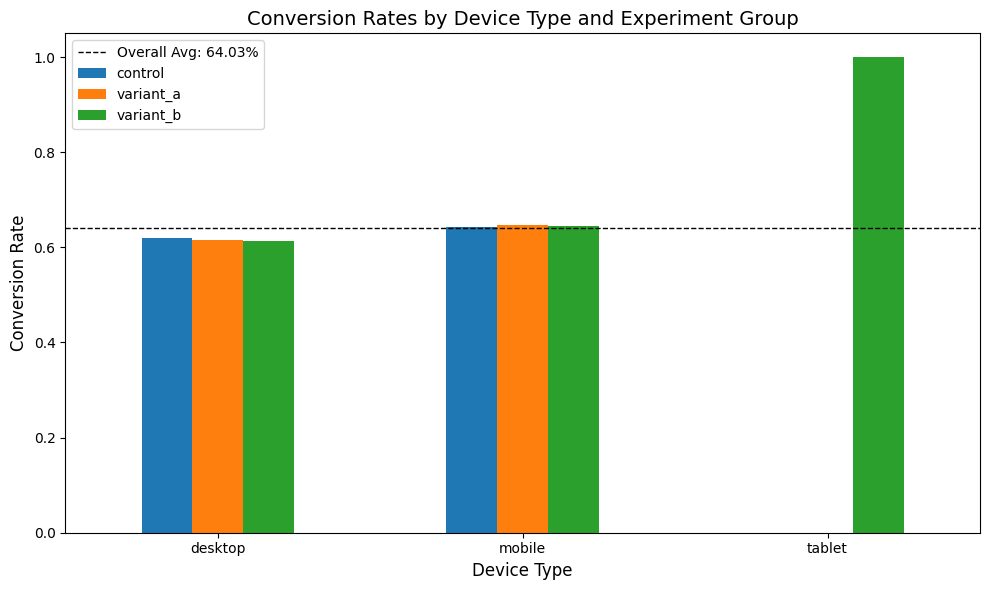

✅ Saved: device_segment_analysis.png


In [13]:
# ============================================
# SAVE DEVICE SEGMENT ANALYSIS CHART
# ============================================

import matplotlib.pyplot as plt
import os

# Create figures directory if it doesn't exist
os.makedirs('../reports/figures', exist_ok=True)

# Plot device segment comparison
fig, ax = plt.subplots(figsize=(10, 6))
device_segment[['control', 'variant_a', 'variant_b']].plot(kind='bar', ax=ax)
ax.set_title('Conversion Rates by Device Type and Experiment Group', fontsize=14)
ax.set_ylabel('Conversion Rate', fontsize=12)
ax.set_xlabel('Device Type', fontsize=12)
ax.legend(title='Group')
ax.axhline(y=df['converted'].mean(), color='black', linestyle='--', linewidth=1, label=f"Overall Avg: {df['converted'].mean():.2%}")
ax.legend()
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../reports/figures/device_segment_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: device_segment_analysis.png")

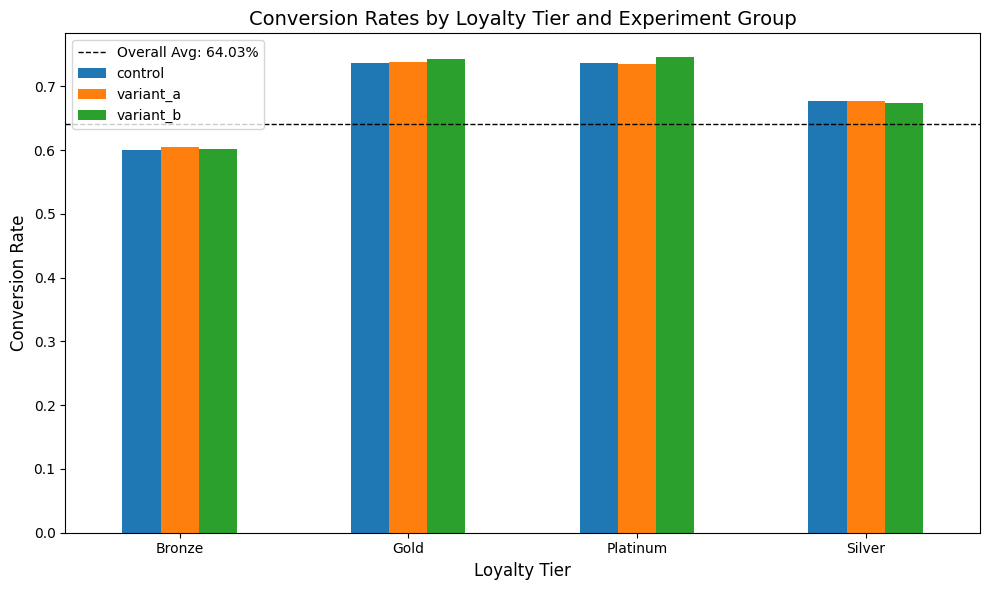

✅ Saved: loyalty_segment_analysis.png


In [14]:
# ============================================
# SAVE LOYALTY SEGMENT ANALYSIS CHART
# ============================================

# Plot loyalty segment comparison
fig, ax = plt.subplots(figsize=(10, 6))
loyalty_segment[['control', 'variant_a', 'variant_b']].plot(kind='bar', ax=ax)
ax.set_title('Conversion Rates by Loyalty Tier and Experiment Group', fontsize=14)
ax.set_ylabel('Conversion Rate', fontsize=12)
ax.set_xlabel('Loyalty Tier', fontsize=12)
ax.legend(title='Group')
ax.axhline(y=df['converted'].mean(), color='black', linestyle='--', linewidth=1, label=f"Overall Avg: {df['converted'].mean():.2%}")
ax.legend()
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../reports/figures/loyalty_segment_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: loyalty_segment_analysis.png")

In [10]:
# ============================================
# SEGMENT LIFT SUMMARY TABLE
# ============================================

import pandas as pd

# Create a clean summary of your key findings
summary_data = []

# Mobile + Variant A
mobile_control = device_segment.loc['mobile', 'control']
mobile_variant_a = device_segment.loc['mobile', 'variant_a']
mobile_lift = device_segment.loc['mobile', 'lift_variant_a']

summary_data.append({
    'Segment': 'Mobile Users',
    'Variant': 'Variant A',
    'Control Conv': f'{mobile_control:.2%}',
    'Treatment Conv': f'{mobile_variant_a:.2%}',
    'Lift': f'{mobile_lift:.2f}%'
})

# Desktop + Variant A (for comparison)
desktop_control = device_segment.loc['desktop', 'control']
desktop_variant_a = device_segment.loc['desktop', 'variant_a']
desktop_lift = device_segment.loc['desktop', 'lift_variant_a']

summary_data.append({
    'Segment': 'Desktop Users',
    'Variant': 'Variant A',
    'Control Conv': f'{desktop_control:.2%}',
    'Treatment Conv': f'{desktop_variant_a:.2%}',
    'Lift': f'{desktop_lift:.2f}%'
})

# Bronze + Variant A
bronze_control = loyalty_segment.loc['Bronze', 'control']
bronze_variant_a = loyalty_segment.loc['Bronze', 'variant_a']
bronze_lift = loyalty_segment.loc['Bronze', 'lift_variant_a']

summary_data.append({
    'Segment': 'Bronze Tier',
    'Variant': 'Variant A',
    'Control Conv': f'{bronze_control:.2%}',
    'Treatment Conv': f'{bronze_variant_a:.2%}',
    'Lift': f'{bronze_lift:.2f}%'
})

# Platinum + Variant B
platinum_control = loyalty_segment.loc['Platinum', 'control']
platinum_variant_b = loyalty_segment.loc['Platinum', 'variant_b']
platinum_lift = loyalty_segment.loc['Platinum', 'lift_variant_b']

summary_data.append({
    'Segment': 'Platinum Tier',
    'Variant': 'Variant B',
    'Control Conv': f'{platinum_control:.2%}',
    'Treatment Conv': f'{platinum_variant_b:.2%}',
    'Lift': f'{platinum_lift:.2f}%'
})

# Create and display DataFrame
summary_df = pd.DataFrame(summary_data)
print("\n" + "=" * 70)
print("KEY SEGMENT OPPORTUNITIES (EDA FINDINGS)")
print("=" * 70)
print(summary_df.to_string(index=False))


KEY SEGMENT OPPORTUNITIES (EDA FINDINGS)
      Segment   Variant Control Conv Treatment Conv   Lift
 Mobile Users Variant A       64.32%         64.74%  0.66%
Desktop Users Variant A       61.89%         61.45% -0.70%
  Bronze Tier Variant A       60.00%         60.46%  0.77%
Platinum Tier Variant B       73.70%         74.60%  1.22%



Conversion Rates by Device and Loyalty Tier:
loyalty_tier  Bronze    Gold  Platinum  Silver
device_type                                   
desktop       0.5746  0.7128    0.7305  0.6601
mobile        0.6061  0.7428    0.7399  0.6795
tablet        1.0000  0.0000       NaN     NaN


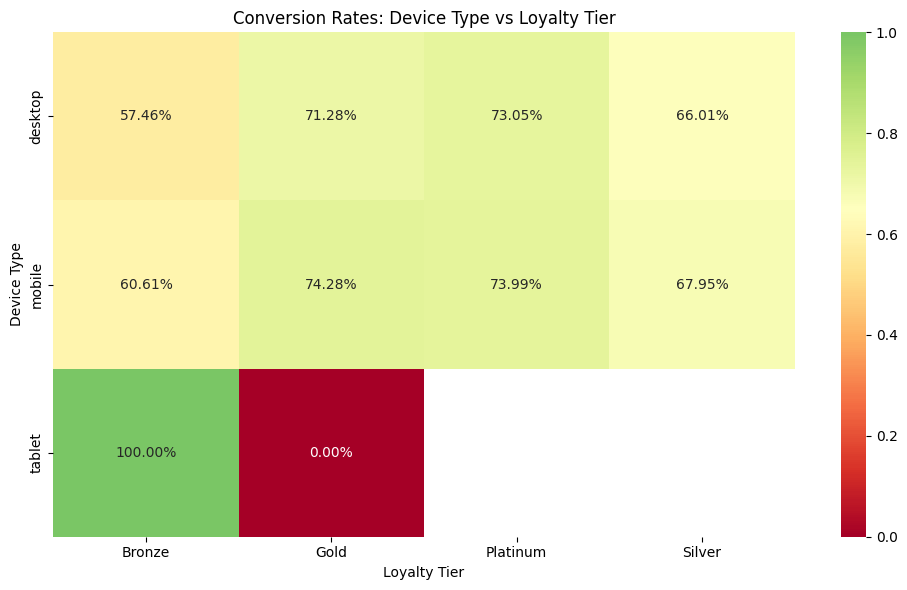

In [7]:
# ============================================
# INTERACTION HEATMAP: Device × Loyalty Tier
# ============================================

# Create a pivot table for conversion rates by device and loyalty
interaction_data = df.pivot_table(
    values='converted', 
    index='device_type', 
    columns='loyalty_tier', 
    aggfunc='mean'
)

print("\nConversion Rates by Device and Loyalty Tier:")
print(interaction_data.round(4))

# Visualize as heatmap
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(interaction_data, annot=True, fmt='.2%', cmap='RdYlGn', center=0.65)
plt.title('Conversion Rates: Device Type vs Loyalty Tier')
plt.xlabel('Loyalty Tier')
plt.ylabel('Device Type')
plt.tight_layout()
plt.savefig('../reports/figures/interaction_heatmap.png', dpi=150)
plt.show()

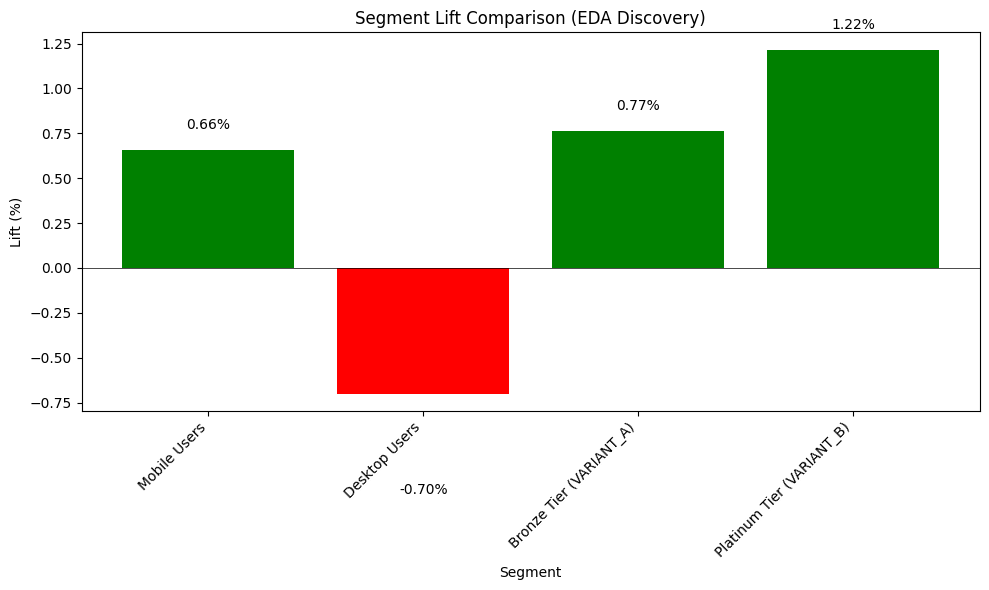

In [11]:
# ============================================
# BAR CHART: Segment Lift Comparison
# ============================================

# Prepare data for plotting
plot_data = []
for seg in ['mobile', 'desktop']:
    plot_data.append({
        'Segment': f'{seg.capitalize()} Users',
        'Lift (%)': device_segment.loc[seg, 'lift_variant_a']
    })

for tier, variant in [('Bronze', 'variant_a'), ('Platinum', 'variant_b')]:
    lift = loyalty_segment.loc[tier, f'lift_{variant}']
    plot_data.append({
        'Segment': f'{tier} Tier ({variant.upper()})',
        'Lift (%)': lift
    })

plot_df = pd.DataFrame(plot_data)

# Create bar chart
plt.figure(figsize=(10, 6))
colors = ['green' if x > 0 else 'red' for x in plot_df['Lift (%)']]
bars = plt.bar(plot_df['Segment'], plot_df['Lift (%)'], color=colors)
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.title('Segment Lift Comparison (EDA Discovery)')
plt.ylabel('Lift (%)')
plt.xlabel('Segment')
plt.xticks(rotation=45, ha='right')

# Add value labels on bars
for bar, lift in zip(bars, plot_df['Lift (%)']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (0.1 if lift > 0 else -0.5),
             f'{lift:.2f}%', ha='center', va='bottom' if lift > 0 else 'top')

plt.tight_layout()
plt.savefig('../reports/figures/segment_lift_comparison.png', dpi=150)
plt.show()

In [ ]:
# ============================================
# HYPOTHESIS FORMULATION (Based on EDA)
# ============================================

print("""
╔══════════════════════════════════════════════════════════════════════╗
║                    EDA SUMMARY & HYPOTHESES                          ║
╚══════════════════════════════════════════════════════════════════════╝

KEY FINDINGS FROM EXPLORATORY ANALYSIS:

1. OVERALL EFFECT:
   - Overall lift across all users: +0.33% (very small)
   - Overall conversion rate: ~64%

2. SEGMENT DISCOVERIES:
   - Mobile users: +0.66% lift with Variant A
   - Desktop users: -0.70% lift with Variant A (negative!)
   - Bronze tier users: +0.77% lift with Variant A
   - Platinum tier users: +1.22% lift with Variant B
   - Silver tier users: Negative or neutral response

3. KEY INSIGHT:
   The treatment effect is NOT uniform. It varies significantly by
   device type and loyalty tier. This suggests we should NOT ship
   to everyone, but target specific segments.

╔══════════════════════════════════════════════════════════════════════╗
║                    HYPOTHESES FOR PHASE 3                            ║
╚══════════════════════════════════════════════════════════════════════╝

NULL HYPOTHESES (H0):
   - H0₁: Variant A has no effect on mobile users
   - H0₂: Variant A has no effect on Bronze tier users
   - H0₃: Variant B has no effect on Platinum tier users
   - H0₄: The difference between mobile and desktop lift is zero

ALTERNATIVE HYPOTHESES (H1):
   - H1₁: Variant A increases conversion for mobile users
   - H1₂: Variant A increases conversion for Bronze tier users
   - H1₃: Variant B increases conversion for Platinum tier users
   - H1₄: Mobile users respond differently than desktop users

╔══════════════════════════════════════════════════════════════════════╗
║                    NEXT STEPS (PHASE 3)                              ║
╚══════════════════════════════════════════════════════════════════════╝

In Phase 3 (Statistical Analysis), we will:
1. Calculate p-values for each segment hypothesis
2. Apply multiple testing correction (Bonferroni)
3. Test if mobile vs desktop difference is statistically significant
4. Calculate revenue impact of targeted recommendations
5. Make final SHIP/NO-SHIP decision with segment strategy
""")

In [12]:
# ============================================
# SAVE ALL FIGURES FOR REPORTS
# ============================================

import os

# Create figures directory if it doesn't exist
os.makedirs('../reports/figures', exist_ok=True)

print("Figures saved to: ../reports/figures/")
print("- device_segment_analysis.png")
print("- loyalty_segment_analysis.png")
print("- interaction_heatmap.png")
print("- segment_lift_comparison.png")

Figures saved to: ../reports/figures/
- device_segment_analysis.png
- loyalty_segment_analysis.png
- interaction_heatmap.png
- segment_lift_comparison.png
